# Training the neural network emulator

This tutorial explains how you can use SPEXAI to train a Neural Network emulator from SPEX data and evualute the preformance of the emulator.

We train a neural network on each of the elements separately: the trained neural networks (30 in total for the 30 different elements), will then be combined to a single model to do model inference.

## Imports

In [1]:
#import liberaries and scripts
import matplotlib.pyplot as plt

import torch
import numpy as np
import glob
import os

from sklearn.model_selection import train_test_split

from spexai.train import dataloader
from spexai.train import train
from spexai.train import plot
from spexai.train import neuralnetwork

from torch.utils.data import Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [14]:
# index of the element to choose
element = '1'

# directory of the training data

fdir = '/Users/danielahuppenkothen/work/data/spexai_data/'

#file directory of training data of specific element
datadir = fdir+'element_'+element+'/'
indexdir = fdir+'Split_data/element_'+element+'/'

#read in the training data
Z01 = dataloader.SpexAIMemoryDataset('Z'+element+'_list_train.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20)

Z01_test = dataloader.SpexAIMemoryDataset('Z'+element+'_list_test.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20)

#apply standard scaler on data
Z01.scale_data()

#split data in train and validation subset
Z01.split_data()


### PCA

Let's take a look at the data, and see if PCA helps:

In [3]:
from sklearn.decomposition import PCA

In [4]:
pca = PCA(n_components=15)
flux_transformed = pca.fit_transform(Z01.flux)

In [5]:
pca.explained_variance_

array([4.17293582e+04, 4.75295222e+00, 4.40342980e-04, 3.87506127e-04,
       2.90213130e-05, 2.62971986e-05, 1.69466844e-05, 5.34779192e-06,
       5.11020917e-06, 3.56216065e-06, 1.70423491e-06, 1.62297774e-06,
       1.14894817e-06, 9.96431110e-07, 6.75759286e-07])

In [6]:
Z01.flux.shape

torch.Size([3590, 18761])

In [7]:
pca.components_.shape

(15, 18761)

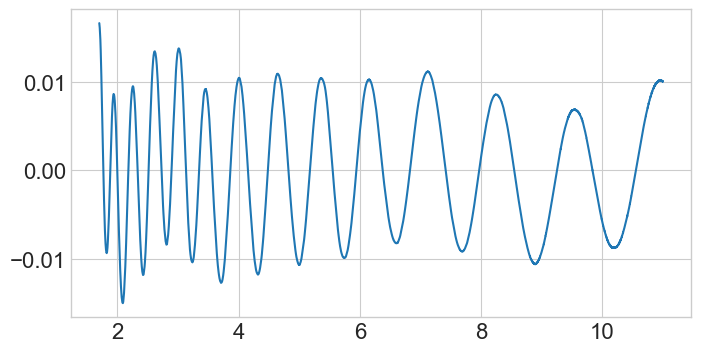

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(Z01.energy, pca.components_[10])

Let's standard-scale the PCA data:

In [9]:
scaler_pca = StandardScaler().fit(flux_transformed)

In [10]:
scaler_flux = StandardScaler().fit(Z01.flux)

In [11]:
scaler_temp = StandardScaler().fit(Z01.temp.reshape(-1,1))

Does it work better if I standard-scale the flux first?

In [15]:
scaler_flux = StandardScaler().fit(Z01.flux)
flux_scaled = scaler_flux.transform(Z01.flux)

flux_transformed2 = pca.fit_transform(flux_scaled)

In [16]:
pca.explained_variance_

array([1.87528955e+04, 1.33303451e+01, 7.61661858e-04, 6.45056833e-04,
       4.69492689e-05, 4.59725974e-05, 2.65894260e-05, 8.96278719e-06,
       8.59790682e-06, 4.19642199e-06, 2.84457231e-06, 2.69105995e-06,
       1.59996485e-06, 1.33742777e-06, 1.14851210e-06])

Actually, not really, so let's not do that.

In [17]:
pca.fit(Z01.flux)

PCA(n_components=15)

Let's make a couple of functions that do the transform and inverse transform

In [12]:
def pca_transform(data, pca, scaler):
    """
    Flatten images, then use the pre-trained PCA estimator 
    to project the pixels down into a small-dimensional space.
    Finally use the pre-trained StandardScaler to scale 
    PCA components to a mean of 0 and a variance of 1.

    Parameters
    ----------
    data : numpy.ndarray
        All training examples. Of form (nsamples, nenergies, ntime)

    pca : sklearn.decomposition.PCA object
        A pre-trained PCA estimator

    scaler : sklearn.preprocessing.StandardScaler object
        A pre-trained standard scaler

    Returns
    -------
    data_pca_scaled : numpy.ndarray
        The preprocessed data. Of form (nsamples, npca)
    """
    data_pca = pca.transform(data)
    data_pca_scaled = scaler.transform(data_pca)

    return data_pca_scaled


def inverse_transform_pca(data_scaled, pca, scaler):

    """
    Do the inverse of the `pca_transform` function:
    take the flattened, PCA-transformed and standard-scaled data, 
    undo the standard-scaling, and inverse-transform from PCA, 
    then reshape into the image shape

    Parameters
    ----------
    data_scaled : numpy.ndarray
        All scaled and transformed training examples
        Of form: (nsamples, npca)

    pca : sklearn.decomposition.PCA object
        A pre-trained PCA estimator

    scaler : sklearn.preprocessing.StandardScaler object
        A pre-trained standard scaler

    Returns
    -------
    data_pca_scaled : numpy.ndarray
        The preprocessed data. Of form (nsamples, nenergy, ntime)
    """
    nsamples = data_scaled.shape[0]
    
    data_pca = scaler.inverse_transform(data_scaled)
    data_data = pca.inverse_transform(data_pca)

    return data


In [13]:

class SpexAIDatasetWithTransform(Dataset):
    def __init__(self, theta, data, data_transform=None, theta_transform=None, pca=None, scaler=None):
        self.theta = torch.tensor(theta).to(torch.float32)

        self.data_transform = data_transform
        self.untransformed_data = data

        if data_transform is not None:
            self.data = torch.tensor(data_transform(data, pca, scaler)).to(torch.float32)
        else:
            self.data = torch.tensor(data).to(torch.float32)

        self.theta_transform = theta_transform

    def __len__(self):
        return len(self.theta)

    def __getitem__(self, idx):
        theta = self.theta[idx]
        data = self.data[idx]
        
        if self.theta_transform:
            theta = self.theta_transform(theta)
        return theta, data

In [19]:
X_train = SpexAIDatasetWithTransform(Z01.temp, Z01.flux, data_transform=pca_transform, pca=pca, scaler=scaler_pca)
X_val = SpexAIDatasetWithTransform(Z01_test.temp, Z01_test.flux, data_transform=pca_transform, pca=pca, scaler=scaler_pca)

/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_6562/1791848143.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.theta = torch.tensor(theta).to(torch.float32)
/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_6562/1791848143.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.theta = torch.tensor(theta).to(torch.float32)


In [ ]:
idx_all = np.random.choice(np.arange(0, len(X_val), 1), size=10)

for idx in idx_all:
    l_test, x_test = X_val[idx]
    d_recon = inverse_flatten_and_transform(x_test.reshape(1, -1), pca, scaler)[0]

    d_true = X_val.untransformed_data[idx]
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 5))
    
    abs_diff = np.abs(d_true - d_recon)
    frac = abs_diff/d_true
    frac[frac == np.inf] = 0.0
    
    ax1.pcolormesh(d_true)
    ax1.set_title("ground truth")
    
    ax2.pcolormesh(d_recon)
    ax2.set_title("PCA reconstruction")
    
    ax3.pcolormesh(frac, vmin=0, vmax=0.5)
    ax3.set_title("Fractional error")
    
    ax4.pcolormesh(abs_diff)
    ax4.set_title("absolute difference")
    

Let's make a Dataset class that will actually work with PyTorch's DataLoader:

In [57]:
class SpexAIPCADataset(Dataset):
    def __init__(self, annotations_file, datadir, indexdir, flux=None, min_flux=None,  size="all",
                 min_energy=None, max_energy=None, min_temp=None, max_temp=None, element=None, pca=None,
                 flux_pca=None, ncomp=10, apply_pca=False, scale=True, scaler_flux=None, scaler_pca=None,
                 scaler_temp=None):

        print(indexdir + annotations_file)
        self.labels = pd.read_csv(indexdir + annotations_file, sep=" ")

        self.datadir = datadir
        self.element = element

        self.min_energy = min_energy
        self.max_energy = max_energy
        self.min_temp = min_temp
        self.max_temp = max_temp

        self.minidx = None
        self.maxidx = None

        self.scale = scale
        self.scaler_flux = None
        self.scaler_temp = None
        self.scaler_pca = None
        self.apply_pca = apply_pca
        self.pca = pca

        self.flux = []
        self.temp = []

        #self.flux_pca = None
        self.flux_scaled = None
        self.flux_scaled_pca= None
        self.temp_scaled = None
        self.energy = None

        # if flux is set, create internal array 
        # from that flux array
        if flux is not None:
            self.temp = []
            self.flux = torch.Tensor(np.array(flux))
            # loop over all the elements in flux 
            # to get out the respective temperatures
            # NOTE THAT THIS ASSUMES THAT THE 
            # TEMPERATURES AND FLUXES HAVE BEEN 
            # LOADED FROM THE SAME FILE!
            for i in range(len(self.flux)):
                idx = self.labels.index[i]
                self.temp.append(self.labels.iloc[idx, 0])
                # for one index, actually run read_data
                # so that the energy array gets set
                if i == 0:
                    t,f = self.read_data(idx)
            self.temp = torch.tensor(self.temp).type(torch.float)
            # check whether the energy and flux arrays have the same 
            # length, because if not, the values for min_energy and 
            # max_energy don't match those that generated the fluxes
            if len(self.energy) != self.flux.shape[1]:
                raise ValueError("min_energy and max_energy in class call not the same " + \
                                 "as those that generated the flux array!")
        else:
            if size == "all":
                for idx in self.labels.index:
                    temp, flux = self.read_data(idx)
                    self.temp.append(temp)
                    self.flux.append(flux)
            else:
                for idx in self.labels.index[:size]:
                    temp, flux = self.read_data(idx)
                    self.temp.append(temp)
                    self.flux.append(flux)

            self.temp = torch.Tensor(self.temp)
            self.flux = torch.Tensor(np.array(self.flux))
        
        #temperature bound
        if self.min_temp is not None:
            self.flux = self.flux[self.temp >= self.min_temp]
            self.temp = self.temp[self.temp >= self.min_temp]
        if self.max_temp is not None:
            self.flux = self.flux[self.temp <= self.max_temp]
            self.temp = self.temp[self.temp <= self.max_temp]

        #create lower flux bound    
        if min_flux is not None:
            #calculate mask
            self.mask = torch.Tensor(self.flux > min_flux)
            self.flux = torch.where(self.flux < (min_flux-5), (min_flux-5), self.flux)

        if self.apply_pca is True and flux_pca is None:
             if self.pca is None:
                 self.pca = PCA(n_components=ncomp)
             flux_pca = torch.Tensor(self.pca.fit_transform(self.flux))
            
        self.flux_pca = flux_pca
        #order the flux on temperature
        sort = torch.argsort(self.temp)
        self.temp = self.temp[sort]
        self.flux = self.flux[sort]
        if self.flux_pca is not None:
            self.flux_pca = self.flux_pca[sort]
        self.mask = self.mask[sort]

        if self.scale is True:
            self.scale_data()

    def __len__(self):
        return len(self.labels)

    def read_data(self, idx):
        data_path = self.labels.iloc[idx,1]
        #data_path = os.path.join(self.datadir + self.labels.iloc[idx, 2])
        data = pd.read_csv(data_path, sep=" ", names=["energy", "flux"])

        if self.minidx is None and self.maxidx is None:
            if self.min_energy is None:
                self.minidx = 0
            else:
                self.minidx = data["energy"].searchsorted(self.min_energy)
            if self.max_energy is None:
                self.maxidx = len(data)-1
            else:
                self.maxidx = data["energy"].searchsorted(self.max_energy)
        flux = data.loc[self.minidx:self.maxidx, "flux"].to_numpy()
        #if len(flux) != 50125:
            #print(data_path)

        if self.energy is None:
            self.energy = data.loc[self.minidx:self.maxidx, "energy"].to_numpy()
        temp = float(self.labels.iloc[idx, 0])
        return temp, flux

    def __getitem__(self, idx):
        if self.scale is False:
            label = self.temp_scaled[idx]
            if self.apply_pca is True:
                flux = self.flux_pca[idx, :]
            else:
                flux = self.flux[idx,:]
        else:
            label = self.temp[idx]
            if self.apply_pca is True:
                flux = self.flux_pca[idx,:]
            else:
                flux = self.flux[idx,:]

        return label, flux
        
    def scale_data(self):
        '''
        Scales the temperature and the flux to a mean=0 and stdev=1.
        '''
        if self.scaler_flux is None:
            self.scaler_flux = StandardScaler().fit(self.flux)
        if self.scaler_temp is None:
            self.scaler_temp = StandardScaler().fit(self.temp.reshape(-1,1))
        self.flux_scaled = torch.Tensor(self.scaler_flux.transform(self.flux))
        self.temp_scaled = torch.Tensor(self.scaler_temp.transform(self.temp.view(len(self.temp), 1)).flatten())
        if self.pca is not None:
            if self.scaler_pca is None:
                self.scaler_pca = StandardScaler().fit(self.flux_pca)
            self.flux_pca_scaled = self.scaler_pca.transform(self.flux_pca)
                            



In [58]:
#read in the training data
Z01_train = SpexAIPCADataset('Z'+element+'_list_train.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20, apply_pca=True,
                                     scaler_flux=scaler_flux, scaler_temp=scaler_temp, 
                                     scaler_pca=scaler_pca)

#read in the test data
Z01_test = SpexAIPCADataset('Z'+element+'_list_test.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20,apply_pca=True,
                                     scaler_flux=scaler_flux, scaler_temp=scaler_temp, 
                                     scaler_pca=scaler_pca)


/Users/danielahuppenkothen/work/data/spexai_data/Split_data/element_1/Z1_list_train.txt
/Users/danielahuppenkothen/work/data/spexai_data/Split_data/element_1/Z1_list_test.txt


### Definining a neural architecture

A neural network model can be defined with the `FFN` class in the `neuralnetwork` submodule, which instantiates a Feed Forward Network (FFN) where you can set the number of layers and neurons per layer, the activation function used and if you want to use dropout. `neuralnetwork.CNN` can in addition to FFN layers also add inverse Convulational layers.

The model below defines a feed-forward neural network with 3 layers and 150 neurons in each layer. It uses the non-linear activation function first introduced in [Alsing et al (2019)](https://ui.adsabs.harvard.edu/abs/2020ApJS..249....5A/abstract). Other possible values for `act_name` are: 
* tanh
* sigmoid
* relu
* elu
* softmax 
* softplus
* nonlin
            

In [59]:
nn_model = neuralnetwork.FFN(1, int(Z01_train.flux_pca.size(1)), 4, 64, act_name='tanh')

### Neural Network training with the PCA data

We're going to use the custom PCA loss:

In [60]:
import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import DataLoader


In [61]:
class PCALoss(nn.Module):
    
    def __init__(self,variances, verbose=False,individual=False):
        super().__init__()
        log_vars_ratios = np.log10(variances/np.min(variances))+1
        self.variances = torch.tensor(log_vars_ratios)
        self.individual = individual
        if verbose==True:
            print(self.variances)
    
    def forward(self,pred,target):
        return self.weightedMSELoss(torch.squeeze(pred),target)
    
    def weightedMSELoss(self,pred,target):
        loss = (pred-target)**2
        weighted_loss = torch.mul(loss,self.variances)
        if self.individual == False:
            return torch.mean(weighted_loss)
        else:
            return torch.mean(weighted_loss,1)


In [62]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices

    train_loss = []
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss.append(loss.detach().numpy())
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 1000 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return np.mean(train_loss)

def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Error: \n Avg loss: {test_loss:>8f} \n")
    return test_loss

In [66]:
learning_rate = 0.0001
batch_size = 256
epochs = 100

loss_fn = PCALoss(Z01_train.pca.explained_variance_)
optimizer = torch.optim.Adam(nn_model.parameters(), lr=learning_rate)

train_dataloader = DataLoader(Z01_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(Z01_test, batch_size=batch_size, shuffle=True)

train_loss_all, test_loss_all = [], []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss_all.append(train_loop(train_dataloader, nn_model, loss_fn, optimizer))
    test_loss_all.append(test_loop(test_dataloader, nn_model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
loss: 42913.126103  [  256/ 3590]
Test Error: 
 Avg loss: 51868.611429 

Epoch 2
-------------------------------
loss: 43133.470931  [  256/ 3590]
Test Error: 
 Avg loss: 51351.367892 

Epoch 3
-------------------------------
loss: 49150.737797  [  256/ 3590]
Test Error: 
 Avg loss: 51566.064887 

Epoch 4
-------------------------------
loss: 47470.723978  [  256/ 3590]
Test Error: 
 Avg loss: 51921.186109 

Epoch 5
-------------------------------
loss: 45368.176971  [  256/ 3590]
Test Error: 
 Avg loss: 54394.736496 

Epoch 6
-------------------------------
loss: 49236.263441  [  256/ 3590]
Test Error: 
 Avg loss: 51361.980841 

Epoch 7
-------------------------------
loss: 45590.445156  [  256/ 3590]
Test Error: 
 Avg loss: 52576.490345 

Epoch 8
-------------------------------
loss: 43597.671963  [  256/ 3590]
Test Error: 
 Avg loss: 52625.283048 

Epoch 9
-------------------------------
loss: 43272.234676  [  256/ 3590]
Test Error: 
 Avg loss

In [60]:
datadir

'/Users/danielahuppenkothen/work/data/spexai_data/element_1/'

In [61]:
indexdir

'/Users/danielahuppenkothen/work/data/spexai_data/Split_data/element_1/'

In [62]:
#read in the training data
Z01_train = SpexAIPCADataset('Z'+element+'_list_train.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20,
                                     scaler_flux=scaler, scaler)

#read in the training data
Z01_train = SpexAIPCADataset('Z'+element+'_list_train.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20)


/Users/danielahuppenkothen/work/data/spexai_data/Split_data/element_1/Z1_list_train.txt


KeyboardInterrupt: 

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)



### Adjusting the NN Trainer class

This is copied and adjusted for use with PCA from the original class in train.py:

In [29]:
import torch
import torch.optim as optim
import time


torch.set_default_dtype(torch.float32)



class NeuralNetworkTrainer(object):
    def __init__(self, X, y, X_test, y_test, model, loss_fn=torch.nn.MSELoss(),
                 optimizer='adam', l_rate=1e-2, lr_factor=0.33, lr_patience=250,
                 lr_threshold=2e-2, lr_mode='rel', lr_cooldown=100, pca=None,
                 scaler_pca = None,
                 scaler_flux=None, mask=None, mask_test=None, f_dir='log/',
                 save_model=False, name=None,  element=00):
        '''
        Trainer class to train a given model on the training data. This class sets up 
        the training process for the neural network.

        Parameters
        ---------
        X: pytorch.Tensor
            training data (temperatures)

        y: pytorch.Tensor
            training data labels (spectra)

        X_test: pytorch.Tensor
            validation data (temperatures)

        y_test : pytorch.Tensor
            validation data (spectra)

        model: torch.Module
            the neural network model

        mask, mask_test: tensor
            this tensor equals one on position where the data is used for training
            (i.e. where the flux in the spectrum is > `min_flux`)
            and 0 for data positions that are excluded in the loss function

        scaler_flux : sklearn.StandardScaler object
            A standard scaler for per-feature scaling of the spectra

        save_model : bool, default False
            If True, save the trained model to disk

        f_dir : str
            The directory where to store the saved model (if `save_model = True`)      

        name : str
            An identifier for a model to be stored

        element : int
            A numerical identifier for the element being trained, used in constructing
            an informative name for the model if saved to disk

        Other Parameters
        ----------------
        loss_fn : torch.nn loss function
            The loss function used for training the neural network

        optimizer : str
            The optimizer to use for training the neural network
            Possible values can be `adam`, `nadam`, `adadelta` or `adagrad`

        l_rate : float
            Learning rate
        lr_factor, lr_patience, lr_treshold, lr_mode, lr_cooldown: 
            Parameters for setting and adjusting the learning rate
 
        '''

        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using {self.device} device")

        self.loss_fn = loss_fn
        self.mask = mask
        self.mask_test = mask_test
        self.scaler_flux = scaler_flux
        self.element = element

        self.pca = pca
        self.scaler_pca = scaler_pca
        self.X = X
        self.y = y
        self.mask = mask
        self.X_test = X_test
        self.y_test = y_test
        self.mask_test = mask_test

        self.f_dir = f_dir
        self.save_model = save_model
        self.name = name

        self.model = model.to(self.device)
        self.optimizer = self._build_optimizer(optimizer, l_rate)
        self.schedular = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min',
                                                                factor=lr_factor,
                                                                patience=lr_patience,
                                                                threshold=lr_threshold,
                                                                threshold_mode=lr_mode,
                                                                cooldown=lr_cooldown)

        self.loss_test = []
        self.loss_train = []

        self.scale = torch.tensor(scaler_flux.scale_, dtype=torch.float32).to(self.device)
        self.mean = torch.tensor(scaler_flux.mean_, dtype=torch.float32).to(self.device)

        if self.pca is not None:
            self.pca_scale = torch.tensor(self.scaler_pca.scale_, dtype=torch.float32).to(self.device)
            self.pca_mean = torch.tensor(self.scaler_pca.mean_, dtype=torch.float32).to(self.device)

    def train(self, nepochs, nbatch):
        '''
        Trains model over `nepochs`  with a batch size of `nbatch`

        Parameters
        ----------
        nepochs : int
            The number of epochs for which to train

        nbatch : int
            The number of training examples in each minibatch
        '''
        time_run = time.time()
        for epoch in range(nepochs):
            self.model.train()
            shuffle = np.random.permutation(len(self.X))
            X_shuffled = self.X[shuffle]
            y_shuffled = self.y[shuffle]
            if self.mask is not None:
                mask_shuffled = self.mask[shuffle]

            loss_batch = 0
            #train model from subset of trainingdata in minibatches
            time_epoch = time.time()
            for i in range(len(self.X)//nbatch):
                X_batch = X_shuffled[i*nbatch:(i+1)*nbatch]
                y_batch = y_shuffled[i*nbatch:(i+1)*nbatch]

                # forward pass
                y_pred = self.model(X_batch.to(self.device)).squeeze(1)

                if self.mask is not None:
                    mask_batch = mask_shuffled[i*nbatch:(i+1)*nbatch]
                    #rescale back to original spectra and look if pred spectra is above minimum flux (-10)
                    print(self.pca)
                    if self.pca is not None:
                        print("I am here")
                        y_pred = torch.add(torch.mul(y_pred, self.pca_scale), self.pca_mean)
                        #y_pred_unscaled = self.pca.inverse_transform(y_pred_pca)
                        #mask_batch = torch.where(torch.Tensor(y_pred_unscaled) > -10, 1, mask_batch.to(self.device))
                    else:
                        print("I am elsewhere")
                        mask_batch = torch.where(torch.add(torch.mul(y_pred, self.scale), self.mean) > -10, 1, mask_batch.to(self.device))
                        y_pred = torch.mul(y_pred, mask_batch.to(self.device))
                        y_batch = torch.mul(y_batch.to(self.device), mask_batch)

                # compute loss
                loss = self.loss_fn(y_pred, y_batch.to(self.device))

                # backward pass
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                loss_batch += loss.item()

            loss_batch /= len(self.X)//nbatch
            self.schedular.step(loss_batch)

            loss_test = self.test(nbatch)

            self.loss_train.append(loss_batch)
            self.loss_test.append(loss_test)
            time_l = time.time()-time_epoch
            #print epoch time every 10% of the model training
            if i==len(self.X)//nbatch-1 and epoch%(0.1*nepochs)==0:
                self.model.eval()
                with torch.no_grad():
                    pred_test = self.model(self.X_test.to(self.device)).squeeze(1).cpu().detach()
                    pred_train = self.model(self.X.to(self.device)).squeeze(1).cpu().detach()
                print('Epoch ({}/{}): Runtime {:.2e} sec, Loss: Test={:.2e};Train={:2e}' .format(epoch, nepochs, time_l,
                                                                        self.original_loss(pred_test, self.y_test, mask = self.mask_test),
                                                                        self.original_loss(pred_train, self.y, mask = self.mask)))


        self.model.eval()
        with torch.no_grad():
            pred_test = self.model(self.X_test.to(self.device)).squeeze(1).cpu().detach()
            pred_train = self.model(self.X.to(self.device)).squeeze(1).cpu().detach()
        print('Epoch ({}/{}): Runtime {:.2e} sec, Loss: Test={:.2e};Train={:2e}' .format(epoch, nepochs, time_l,
                                                                self.original_loss(pred_test, self.y_test, mask = self.mask_test),
                                                                self.original_loss(pred_train, self.y, mask = self.mask)))
        print('Time of the run is {:.2e} hrs \n'.format((time.time()-time_run)/3600))

        if self.save_model == True:
            self.save()

    def test(self, nbatch):
        '''
        Calculates the average loss given a current model on a validation 
        or test data set

        Parameters
        -----
        nbatch: int
            the size of the minibatch over which to compute the loss function        

        Returns
        -------
        loss_test: float
            Average validation/test loss

        '''
        #intit
        self.model.eval()
        loss_test = 0

        # shuffle the testdata (therefor minibatch are diff each time)
        shuffle = np.random.permutation(len(self.X_test))
        X_test_shuffled = self.X_test[shuffle]
        y_test_shuffled = self.y_test[shuffle]
        if self.mask_test is not None:
            mask_test_shuffle = self.mask_test[shuffle]


        with torch.no_grad():
            #calculate loss of testdata in minibatches
            for i in range(len(self.X_test)//nbatch):
                X_test_batch = X_test_shuffled[i*nbatch:(i+1)*nbatch].to(self.device)
                y_test_batch = y_test_shuffled[i*nbatch:(i+1)*nbatch]

                #forward
                y_test_pred = self.model(X_test_batch)

                if self.mask_test is not None:
                    mask_test_batch = mask_test_shuffle[i*nbatch:(i+1)*nbatch]
                    mask_test_batch = torch.where(torch.add(torch.mul(y_test_pred, self.scale), self.mean) > -10, 1, mask_test_batch.to(self.device))
                    y_test_pred = torch.mul(y_test_pred, mask_test_batch.to(self.device))
                    y_test_batch = torch.mul(y_test_batch.to(self.device), mask_test_batch)

                loss_test += self.loss_fn(y_test_pred, y_test_batch.to(self.device)).item()

        loss_test /= (len(self.X_test)//nbatch) #avg loss

        return loss_test
   
    def predict(self, X):
        '''
        Model prediction for a given temperature or array of 
        temperatures. 

        Paramters
        ---------
        X: Tensor
            Set of temperatures for which to predict
            the spectrum

        Returns
        -------
        ypred : pytorch.Tensor
             The predicted spectra for the temperatures stored 
             in `X`
        '''
        self.model.eval()
        X = X.to(self.device)
        return self.model(X)

    def save(self):
        '''
        Save the trained model to a pickle file with the name and date of the model
        '''
        #give_data

        date = datetime.datetime.now()
        date_name = str(date.day)+'|'+str(date.month)
        try:
            os.makedirs(os.path.join('log','Z'+str(self.element), date_name))
        except:
            pass

        if self.name is not None:
            torch.save(self.model.state_dict(), 'log/'+'Z'+str(self.element)+'/'+date_name+'/'+self.name+'.pt')
            np.savetxt('log/'+'Z'+str(self.element)+'/'+date_name+'/'+self.name+'_Loss_train.txt', self.loss_train)
            np.savetxt('log/'+'Z'+str(self.element)+'/'+date_name+'/'+self.name+'_Loss_test.txt', self.loss_test)
        else:
            torch.save(self.model.state_dict(), 'log/'+'Z'+str(self.element)+'/'+date_name+'/'+str(self.model)+'.pt')
            np.savetxt('log/'+'Z'+str(self.element)+'/'+date_name+'/'+str(self.model)+'_Loss_train.txt', self.loss_train)
            np.savetxt('log/'+'Z'+str(self.element)+'/'+date_name+'/'+str(self.model)+'_Loss_test.txt', self.loss_test)

    def load(self, model_dir):
        '''
        Load a trained model from file.

        Parameters
        ----------
        model_file : str
            Path to saved `state_dict` of model

        '''
        self.model = torch.load(model_dir).to(self.device)
        self.loss_test = np.loadtxt(model_dir+'_Loss_test')
        self.loss_train = np.loadtxt(model_dir+'_Loss_train')

    def _build_optimizer(self, optimizer, learning_rate):
        '''
        Initializes the optimzer
        Parameters
        ----------
        optimizer: str
            Name of the optimzer
        learning rate: float
        '''
        if optimizer == "adam":
            optimizer = optim.Adam(self.model.parameters(),
                                lr=learning_rate)
        elif optimizer == "nadam":
            optimizer = optim.NAdam(self.model.parameters(),
                                lr=(learning_rate*2))
        elif optimizer == "adadelta":
            optimizer = optim.Adadelta(self.model.parameters(),
                                lr=(learning_rate*1e3))
        elif optimizer == "adagrad":
            optimizer = optim.Adagrad(self.model.parameters(),
                                lr=(learning_rate*10))
        return optimizer
    def original_loss(self,  pred,  original, mask=None):
        '''
        This defines the custom loss function we use in training the emulator. 
        It calculates the loss function defined in the `loss_fn` attribute, but if 
        a `mask` is set, regions where the value of `mask` = 0 will only contribute 
        to the loss function if the emulated value is above the critical value, and 
        ignored otherwise (with the assumption that it will be small enough not to  
        contribute to the flux in a meaningful way. This helps the network focus on 
        training in those areas where the flux most contributes to the observed spectrum

        Parameters
        ----------
        pred : torch.Tensor
            the spectrum fluxes predicted by the neural network

        original : torch.Tensor
            the training data for the same temperature as the predicted spectrum

        mask : torch.Tensor
            a boolean mask to apply to the spectra, where the loss function will 
            only be calculated for energy bins where mask == 1 or where the predicted 
            flux exceeds the threshold. 

        '''
        #calculate loss for original spectra
        if mask is None:
            if self.scaler_flux is None:
                loss = self.loss_fn(torch.pow(10, pred), torch.pow(10, original)).item()
            else:
                pred = torch.from_numpy(self.scaler_flux.inverse_transform(pred))
                original = torch.from_numpy(self.scaler_flux.inverse_transform(original))
                loss = self.loss_fn(torch.pow(10, pred), torch.pow(10, original)).item()
        else:   
            #calculate loss on region where flux is above minimum
            if self.scaler_flux is None:
                mask = mask > 0
                loss = self.loss_fn(torch.pow(10, pred[mask]), torch.pow(10, original[mask])).item()
            else:
                #calculate loss over original spectrum
                mask = mask > 0
                pred = torch.from_numpy(self.scaler_flux.inverse_transform(pred))
                original = torch.from_numpy(self.scaler_flux.inverse_transform(original))
                loss = self.loss_fn(torch.pow(10, pred[mask]), torch.pow(10, original[mask])).item()
        return loss



In [31]:
nn_model = neuralnetwork.FFN(1, int(Z01.flux_pca.size(1)), 4, 64, act_name='nonlin')
#train on Hydrogen (H): Z1
element = '1'

# mask on the training and validation data set
mask_train = torch.where(Z01.mask_train, 1., 0).type(torch.float32)
mask_test = torch.where(Z01.mask_test, 1., 0).type(torch.float32)

#train neural network
model = NeuralNetworkTrainer(Z01.x_scaled_train, Z01.y_pca_train,
                                   Z01.x_scaled_test, Z01.y_pca_test, 
                                   nn_model, scaler_flux=Z01.scaler_flux, 
                                   #mask=mask_train, mask_test=mask_test, 
                                   pca=pca,scaler_pca=Z01.scaler_pca,
                                   save_model=False, element=element, l_rate=0.01)

model.train(1000, 512)

Using cpu device


ValueError: operands could not be broadcast together with shapes (584,15) (18761,) (584,15) 

### Train the neural network emulator on the training data

The learning algorithm ```train.NeuralNetworkTrainer``` will train the NN on the training data from spex. The learning algorithm can also be adjusted with different hyperparameters, the optimizer, loss function and critearia for the learningrate regulazir can be changed. In adition ```mask``` and ```mask_test``` can be used to mask out part of the parameter space from the loss-calculation if the flux in this region is low enhough. This mask is defined when the `min_flux` parameter is set during instantiation of the `DataLoader` object (i.e. in our current example, it will mask our regions where the log(flux) < -10). 

We also include the scikit-learn `StandardScaler` trained during the instantiation of the `DataLoader` object: this is to normalize the training data on a per-feature basis (i.e. standardization per energy bin) to help the neural network train.

The `save_model` keyword enables the user to decide whether to save the model to file, using the standard PyTorch `save()` function. Note that this will use the Python `pickle` functionality to save the model, and is not recommended for long-term storage (because `pickle` sensitively depends on the details of the current Python environment). 

In [12]:
Z01.x_scaled_train

tensor([0.5015, 0.5020, 0.5024,  ..., 9.9814, 9.9900, 9.9947])

In [15]:
Z01.y_scaled_pca_train

tensor([[-5.3171e+02, -2.6427e+00, -4.7765e-04,  ...,  1.6666e-03,
          7.3495e-04,  5.2945e-04],
        [-5.3097e+02, -2.6342e+00, -2.5685e-04,  ...,  1.6686e-03,
          7.0610e-04,  5.6254e-04],
        [-5.3035e+02, -2.6271e+00, -7.5940e-05,  ...,  1.6686e-03,
          6.7877e-04,  5.8579e-04],
        ...,
        [ 2.1180e+02, -3.3026e+00,  3.2047e-02,  ..., -1.4190e-03,
          9.1953e-04,  1.2338e-03],
        [ 2.1183e+02, -3.3065e+00,  3.2090e-02,  ..., -1.4207e-03,
          8.6451e-04,  1.2754e-03],
        [ 2.1185e+02, -3.3085e+00,  3.2112e-02,  ..., -1.4212e-03,
          8.3478e-04,  1.2976e-03]])

In [20]:
#train on Hydrogen (H): Z1
element = '1'

# mask on the training and validation data set
mask_train = torch.where(Z01.mask_train, 1., 0).type(torch.float32)
mask_test = torch.where(Z01.mask_test, 1., 0).type(torch.float32)

#train neural network
model = train.NeuralNetworkTrainer(Z01.x_scaled_train, Z01.y_scaled_pca_train,
                                   Z01.x_scaled_test, Z01.y_scaled_pca_test, 
                                   nn_model, scaler_flux=Z01.scaler_flux, 
                                   mask=mask_train, mask_test=mask_test, 
                                   pca=pca,
                                   save_model=False, element=element, l_rate=0.01)

model.train(1000, 512)

Using cpu device


AttributeError: 'NeuralNetworkTrainer' object has no attribute 'pca'

In [ ]:
aaa

### Reading in the training data

The Neural Network (NN) emulator is trained on spectra generated by SPEX at different temperatures between 0.2 keV and 25 KeV. For each element, we generate a grid of temperatures and the associated spectrum for that element at that temperature. Each spectrum is saved in a text file, where the first column is flux and the second column is energy bins. To associate these files with their respective temperature values, an index file should exist: a text file that lists the temperature in the first column and the file name of the associated spectrum in the second.

### Making an Index File

Let's make an index file:

In [2]:
# index of the element to choose
element = 1

# directory of the training data
fdir = '/Users/danielahuppenkothen/work/data/spexai_data/'

# directory for this particular element
eldir = f"{fdir}element_{element}/"
 
print(eldir)

/Users/danielahuppenkothen/work/data/spexai_data/element_1/


Now we can find all the files in that directory:

In [3]:
specfiles = glob.glob(eldir + "*keV.txt")

In [4]:
index = []
for s in specfiles:
    en = s.split("_")[-1][:-7]
    index.append([en, s])

index = np.array(index)

How many training samples do I have?

In [5]:
ndata = len(index)
print(f"There are {ndata} spectra in the whole training data set.")

There are 3991 spectra in the whole training data set.


Let's split pretty aggressively into train/test data, since I don't have the full data set:

In [6]:
ntrain = int(0.9*ndata)
ntest = ndata - ntrain

print(f"There will be {ntrain} samples in the training data, and {ntest} samples in the test data.")

There will be 3591 samples in the training data, and 400 samples in the test data.


Now we can use scikit-learn to split the data:

In [8]:
index_train, index_test = train_test_split(index, train_size=0.9)

print(f"There are {len(index_train)} training examples and {len(index_test)} test examples")

There are 3591 training examples and 400 test examples


Ok, cool, let's save those to files:

In [9]:
fdir

'/Users/danielahuppenkothen/work/data/spexai_data/'

In [10]:
# Comment out the lines below if the relevant folders already exist:
#os.mkdir(f"{fdir}Split_data/")
#os.mkdir(f"{fdir}Split_data/element_{element}/")

In [11]:
np.savetxt(f"{fdir}Split_data/element_{element}/Z{element}_list_train.txt", index_train, fmt='%s' )
np.savetxt(f"{fdir}Split_data/element_{element}/Z{element}_list_test.txt", index_test, fmt='%s' )


Let's loop over all of the remaining files:

In [12]:
nelement = 30

for element in range(2, 31, 1):
    # directory for this particular element
    eldir = f"{fdir}element_{element}/" 
    print(eldir)
    specfiles = glob.glob(eldir + "*.txt")

    index = []
    for s in specfiles:
        en = s.split("_")[-1][:-7]
        index.append([en, s])

    index = np.array(index)
    
    ndata = len(index)
    print(f"There are {ndata} spectra in the whole training data set.")

    index_train, index_test = train_test_split(index, train_size=0.9)
    print(f"There are {len(index_train)} training examples and {len(index_test)} test examples")

    # uncomment if the relevant folders don't already exist to create them
    #os.mkdir(f"{fdir}Split_data/element_{element}/")

    np.savetxt(f"{fdir}Split_data/element_{element}/Z{element}_list_train.txt", index_train, fmt='%s' )
    np.savetxt(f"{fdir}Split_data/element_{element}/Z{element}_list_test.txt", index_test, fmt='%s' )


/Users/danielahuppenkothen/work/data/spexai_data/element_2/
There are 3994 spectra in the whole training data set.
There are 3594 training examples and 400 test examples
/Users/danielahuppenkothen/work/data/spexai_data/element_3/
There are 3995 spectra in the whole training data set.
There are 3595 training examples and 400 test examples
/Users/danielahuppenkothen/work/data/spexai_data/element_4/
There are 3995 spectra in the whole training data set.
There are 3595 training examples and 400 test examples
/Users/danielahuppenkothen/work/data/spexai_data/element_5/
There are 3992 spectra in the whole training data set.
There are 3592 training examples and 400 test examples
/Users/danielahuppenkothen/work/data/spexai_data/element_6/
There are 3996 spectra in the whole training data set.
There are 3596 training examples and 400 test examples
/Users/danielahuppenkothen/work/data/spexai_data/element_7/
There are 3997 spectra in the whole training data set.
There are 3597 training examples an

You will need to set the variable `fdir` below to the directory where the training data is stored. In this directory, the code below expects subdirectories of the form `element_X` where `X` is a number between 1 and 30, corresponding to the thirty elements currently being used in Spex for calculating spectra. In addition, index files are similarly under  `Split_data/element_X/` directories. The code assumes that there are two index files in that directory: one each for the training and test data. Throughout training, we will further split the training data into a training and a validation set, and leave the test set untouched until we have optimized our hyperparameters and are finished with model construction.

These text files can be read with ```spexai.train.SpexAIMemoryDataset``` and then standard-scaled (using the scikit-learn standard-scaler). The DataLoader can consider subsets of the available training data: in particular, it can consider subsets of temperatures (below, we consider temperatures between 0.2 and 10 keV) and also subsets of energy (the energy grid created by SPEX might be wider than that of the instrument for which the emulator is trained). 

The parameter `min_flux` sets a minimum flux for which we want the emulator to approximate the spectrum. The reasoning is that below a certain flux, we will never be able to see any emission in real spectra anyway, and emulating the spectrum precisely below that value is superfluous. Be sure that this parameter is set to the same value both here in the `DataLoader`, and later during training: the loss function will not try to optimize anything below that value.

In [3]:
# index of the element to choose
element = '1'

# directory of the training data

fdir = '/Users/danielahuppenkothen/work/data/spexai_data/'

#file directory of training data of specific element
datadir = fdir+'element_'+element+'/'
indexdir = fdir+'Split_data/element_'+element+'/'

#read in the training data
Z01 = dataloader.SpexAIMemoryDataset('Z'+element+'_list_train.txt', 
                                     datadir, indexdir, min_flux=-10.,
                                     min_energy=1.7, max_energy=11 , 
                                     min_temp=0.2, max_temp=20)
#apply standard scaler on data
Z01.scale_data()

#split data in train and validation subset
Z01.split_data()


If you set `save_model = False`, you can always save it later by using the `save` method:

In [44]:
model.save()

The location and details of the filename can be set using the `f_dir` (target directory), `name` and `element` keywords when instantiating the `NeuralNetworkTrainer` class above. By default, the model will be saved in a `log` directory in the current working directory (so if you don't change the values above, check in the directory where this notebook is housed), and will be stored in subdirectories created based on the element number, the day when the model was saved (to allow distinguishing between models trained on different days). The filename will include details of the neural network architecture, the activation function and whether dropout is used. 

### Evaluate the training

you can also load in an model that has already been trained with ```train.NeuralNetworkTrainer.load``` and you can evualu the preformce of the NN emulator by looking at the loss function and the error fraction between the orginal SPEX spectra's and the  spectra's predicted by the NN emulator.

In [45]:
#load model
#model.load('/Best_NN/Z1/FF_out(50125)_nL(3|150)_Act(tanh)_p(0.0)')

Loss on test data is 2.702e-12


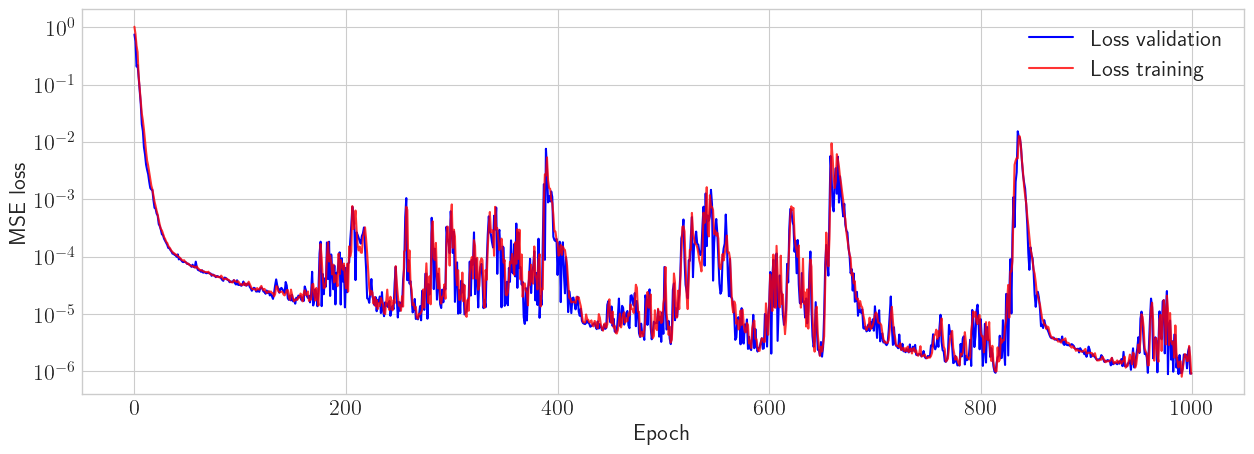

In [46]:
#print the mean squeared error over the validation dataset
print('Loss on test data is {:.3e}'.format(model.original_loss(model.model(Z01.x_scaled_test.to(model.device)).cpu().detach(), Z01.y_scaled_test)))

#plot the loss per epoch
plot.loss(model.loss_train, model.loss_test)

Show the error fraction in the 2D plot for differrent temperatures and energies, and show if points around a critical error fraction 1e-3 by having a split colorbar.

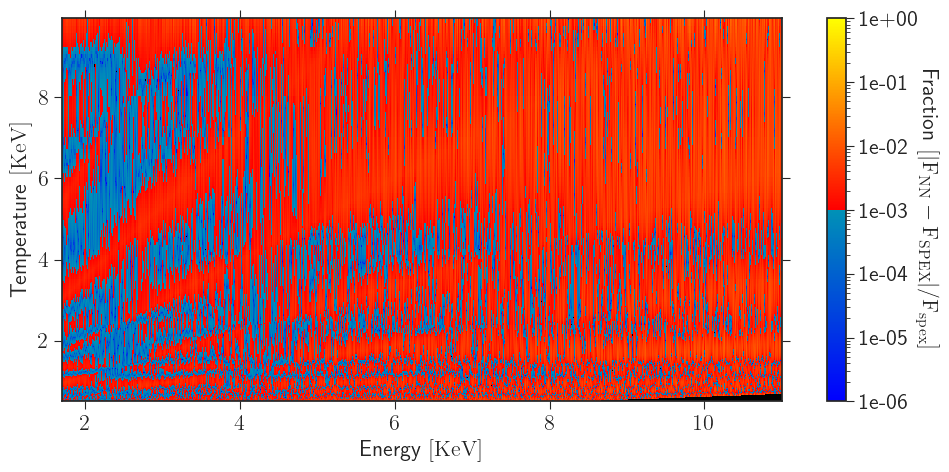

N_points above f_(10^(-3)) = 1571604; This is 14.6% of N_total
N_points above f_(10^(-2)) = 15814; This is 0.147% of N_total


In [47]:
#draw predicted spectra's from the NN emulator
y_pred = Z01.power(model.predict(Z01.x_scaled_test))
y      = Z01.power(Z01.y_test, scaler=False)

#calculate error fraction between predicted spectra and validation spectra's
frac = dataloader.fraction(y_pred, y, absolute=False)

#plot the error fraction in the 2D plot for diff. temperatures and energies, and show if points around a critical error fraction 1e-3
plot.heatmap(Z01.energy, Z01.x_test, frac, Z01.mask_test, color='seismic', Z_center=-3)

Temperature is 9.922 KeV with MSE-loss of 4.541e-11


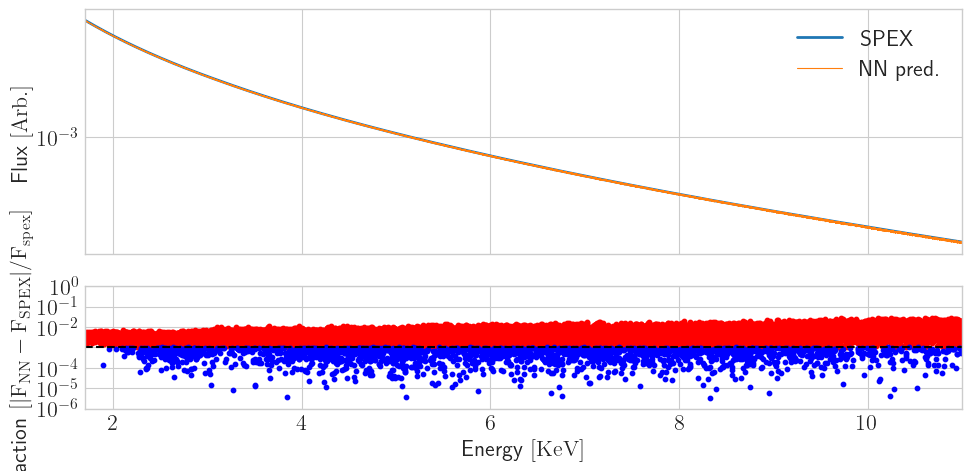

Energy of the maximum is 1.7003 [KeV]


In [52]:
#plot a spectra of spex and the spectra predicted by the NN at temperature of 5 KeV
temp = 15.0
plot.fraction([temp], Z01.x_test, y_pred, y, Z01.mask_test, Z01.energy)
